# DATA 266 Assignment 3: Prompt Engineering and Self Attention from Scratch


## 1. Prompt Engineering Techniques

Six techniques, two worked examples each, executed through LangChain against a local
llama3.1 8B model (Ollama). The same two tasks are used throughout so the comparison
isolates the prompting technique rather than the question.

Task A is a math word problem with a rate that changes partway through, ground truth
9:48 am. Task B is a seating logic puzzle, ground truth Eli. Both are verified in Python
below rather than asserted by hand.

To rerun this section, Ollama must be installed and running locally with the model pulled:
`ollama pull llama3.1` then `ollama serve` (or start the Ollama desktop app), before
executing the cells below.


In [1]:
import json
import re
import textwrap
import urllib.request

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate, FewShotChatMessagePromptTemplate, PromptTemplate
from langchain_ollama import ChatOllama

MODEL = "llama3.1:latest"


def find_ollama(ports=(11434, 11435)):
    body = json.dumps({"model": MODEL, "prompt": "hi", "stream": False,
                       "options": {"num_predict": 1}}).encode()
    for port in ports:
        url = f"http://127.0.0.1:{port}"
        req = urllib.request.Request(f"{url}/api/generate", data=body,
                                     headers={"Content-Type": "application/json"})
        try:
            with urllib.request.urlopen(req, timeout=120) as resp:
                json.load(resp)
            return url
        except Exception:
            pass
    raise RuntimeError("No Ollama server able to run " + MODEL)


llm = ChatOllama(model=MODEL, base_url=find_ollama(), temperature=0.0, seed=42, num_predict=900)


def show(text, width=95):
    for para in str(text).strip().split("\n"):
        print(textwrap.fill(para, width=width) if para.strip() else "")


def extract_final_answer(text):
    marked = re.findall(r"FINAL ANSWER:\s*(.+)", text, flags=re.IGNORECASE)
    if marked:
        return marked[-1].strip()
    stated = re.findall(r"[Tt]he answer is\s*(.+)", text)
    if stated:
        return stated[-1].strip()
    lines = [ln.strip() for ln in text.strip().splitlines() if ln.strip()]
    return lines[-1] if lines else ""


def score_task_a(text):
    return bool(re.search(r"9:48", extract_final_answer(text)))


def score_task_b(text):
    final = extract_final_answer(text).lower()
    named = {n for n in ["ana", "ben", "cleo", "dev", "eli"] if re.search(rf"\b{n}\b", final)}
    return named == {"eli"}


RESULTS = []


def record(technique, task, output, n_calls=1):
    correct = score_task_a(output) if task == "A" else score_task_b(output)
    final = extract_final_answer(output)
    RESULTS.append({"technique": technique, "task": task, "final_answer": final,
                     "correct": correct, "llm_calls": n_calls, "output_chars": len(output)})
    truth = "9:48 am" if task == "A" else "Eli"
    print(f"committed answer: {final[:70]}")
    print(f"ground truth: {truth}  verdict: {'CORRECT' if correct else 'WRONG'}")
    return correct


print("LLM ready:", MODEL)


LLM ready: llama3.1:latest


In [2]:
TASK_A = (
    "A tank holds 240 liters of water. A drain removes 6 liters per minute while a pipe adds "
    "2.5 liters per minute. Both start at 9:00 am, and the pipe is shut off after 20 minutes "
    "while the drain keeps running. At what time is the tank empty?"
)

TASK_B = (
    "Five students (Ana, Ben, Cleo, Dev and Eli) sit in a row of five chairs numbered 1 to 5 "
    "from left to right. Cleo sits immediately to the right of Ana. Ben sits in chair 1. "
    "Dev sits immediately to the left of Eli. Eli does not sit in chair 5. Who sits in chair 3?"
)

show(TASK_A)
print()
show(TASK_B)


A tank holds 240 liters of water. A drain removes 6 liters per minute while a pipe adds 2.5
liters per minute. Both start at 9:00 am, and the pipe is shut off after 20 minutes while the
drain keeps running. At what time is the tank empty?

Five students (Ana, Ben, Cleo, Dev and Eli) sit in a row of five chairs numbered 1 to 5 from
left to right. Cleo sits immediately to the right of Ana. Ben sits in chair 1. Dev sits
immediately to the left of Eli. Eli does not sit in chair 5. Who sits in chair 3?


In [3]:
# Ground truth A: split the timeline at the 20 minute mark.
net_rate = 6 - 2.5
remaining = 240 - net_rate * 20
total_minutes = 20 + remaining / 6
secs = round(total_minutes * 60)
print(f"GROUND TRUTH A: tank empty at 9:{secs // 60:02d}:{secs % 60:02d} am")

# Ground truth B: brute force over all 120 seatings.
from itertools import permutations

names = ["Ana", "Ben", "Cleo", "Dev", "Eli"]
solutions = []
for perm in permutations(names):
    pos = {name: i + 1 for i, name in enumerate(perm)}
    if pos["Cleo"] == pos["Ana"] + 1 and pos["Ben"] == 1 and pos["Eli"] == pos["Dev"] + 1 and pos["Eli"] != 5:
        solutions.append(perm)
print(f"GROUND TRUTH B: chair 3 is {solutions[0][2]} ({len(solutions)} seating satisfies every constraint)")


GROUND TRUTH A: tank empty at 9:48:20 am
GROUND TRUTH B: chair 3 is Eli (1 seating satisfies every constraint)


### 1.1 Zero Shot Prompting

The question is handed to the model with no examples and an instruction to give only the
final answer.

#### 1.1.1 Example 1


In [4]:
zero_shot_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant. Answer the question directly."),
    ("human", "{question}\n\nGive only the final answer, with no explanation."),
])
zero_shot_chain = zero_shot_prompt | llm | StrOutputParser()

out = zero_shot_chain.invoke({"question": TASK_A})
show(out)
record("Zero Shot", "A", out)


9:40 am
committed answer: 9:40 am
ground truth: 9:48 am  verdict: WRONG


False

#### 1.1.2 Example 2

In [5]:
out = zero_shot_chain.invoke({"question": TASK_B})
show(out)
record("Zero Shot", "B", out)


Cleo
committed answer: Cleo
ground truth: Eli  verdict: WRONG


False

#### 1.1.3 Comparison and Findings

Both tasks were answered wrong (9:40 am instead of 9:48 am, and Cleo instead of Eli), with
no hedging in either response. Zero Shot gives the model no mechanism to reason its way to
either answer.


### 1.2 Few Shot Prompting

Three solved examples of the same kind of problem are shown before the real question, with
only the question and final answer, no working shown. This isolates what in context examples
contribute on their own.

#### 1.2.1 Example 1


In [6]:
math_examples = [
    {"question": "A barrel holds 100 liters. A tap drains 4 liters per minute while a hose adds "
                 "1 liter per minute. Both run from 2:00 pm. When is the barrel empty?",
     "answer": "2:33:20 pm"},
    {"question": "A pool holds 90 liters. A pump removes 5 liters per minute and an inlet adds "
                 "2 liters per minute, both starting at 1:00 pm. When is the pool empty?",
     "answer": "1:30 pm"},
    {"question": "A bucket holds 60 liters and a drain removes 8 liters per minute starting at "
                 "7:00 am. When is the bucket empty?",
     "answer": "7:07:30 am"},
]
example_prompt = ChatPromptTemplate.from_messages([("human", "{question}"), ("ai", "{answer}")])

few_shot_math_prompt = ChatPromptTemplate.from_messages([
    ("system", "You solve tank and rate word problems. Answer in the same style as the examples."),
    FewShotChatMessagePromptTemplate(example_prompt=example_prompt, examples=math_examples),
    ("human", "{question}"),
])
few_shot_math_chain = few_shot_math_prompt | llm | StrOutputParser()

out = few_shot_math_chain.invoke({"question": TASK_A})
show(out)
record("Few Shot", "A", out)


9:34 am
committed answer: 9:34 am
ground truth: 9:48 am  verdict: WRONG


False

#### 1.2.2 Example 2

In [7]:
logic_examples = [
    {"question": "Three friends (Mia, Noah, Ola) sit in chairs 1 to 3 from left to right. "
                 "Noah sits immediately to the right of Mia. Who sits in chair 3?",
     "answer": "Ola"},
    {"question": "Four people (Pia, Quinn, Rosa, Sam) sit in chairs 1 to 4 from left to right. "
                 "Sam sits in chair 4. Quinn sits immediately to the left of Rosa. "
                 "Pia sits in chair 1. Who sits in chair 3?",
     "answer": "Rosa"},
    {"question": "Four runners (Tam, Uma, Vik, Wes) finish in places 1 to 4. Uma finishes "
                 "immediately after Tam. Wes finishes last. Tam finishes first. Who is third?",
     "answer": "Vik"},
]
few_shot_logic_prompt = ChatPromptTemplate.from_messages([
    ("system", "You solve seating and ordering puzzles. Answer in the same style as the examples."),
    FewShotChatMessagePromptTemplate(example_prompt=example_prompt, examples=logic_examples),
    ("human", "{question}"),
])
few_shot_logic_chain = few_shot_logic_prompt | llm | StrOutputParser()

out = few_shot_logic_chain.invoke({"question": TASK_B})
show(out)
record("Few Shot", "B", out)


Cleo
committed answer: Cleo
ground truth: Eli  verdict: WRONG


False

#### 1.2.3 Comparison and Findings

The answer only examples taught the model the bare reply format, but the math answer only
moved from one wrong value to another (9:34 am). Few Shot changes the output format, not the
reasoning quality.


### 1.3 Chain of Thought (CoT) Prompting

The same three exemplars as Few Shot, but each answer now shows its intermediate steps
(Wei et al. 2022). The only variable that changed is the reasoning demonstration.

#### 1.3.1 Example 1


In [8]:
cot_math_examples = [
    {"question": math_examples[0]["question"],
     "answer": "While both run, the net drain rate is 4 - 1 = 3 liters per minute. "
               "The barrel holds 100 liters, so it takes 100 / 3 = 33.33 minutes, which is "
               "33 minutes and 20 seconds. Starting at 2:00 pm, the barrel is empty at "
               "2:33:20 pm. The answer is 2:33:20 pm."},
    {"question": math_examples[1]["question"],
     "answer": "The net drain rate is 5 - 2 = 3 liters per minute. The pool holds 90 liters, "
               "so it takes 90 / 3 = 30 minutes. Starting at 1:00 pm, the pool is empty at "
               "1:30 pm. The answer is 1:30 pm."},
    {"question": math_examples[2]["question"],
     "answer": "Only the drain is running, at 8 liters per minute. The bucket holds 60 liters, "
               "so it takes 60 / 8 = 7.5 minutes, which is 7 minutes and 30 seconds. Starting "
               "at 7:00 am, the bucket is empty at 7:07:30 am. The answer is 7:07:30 am."},
]
cot_math_prompt = ChatPromptTemplate.from_messages([
    ("system", "You solve tank and rate word problems. Show your reasoning like the examples do."),
    FewShotChatMessagePromptTemplate(example_prompt=example_prompt, examples=cot_math_examples),
    ("human", "{question}"),
])
cot_math_chain = cot_math_prompt | llm | StrOutputParser()

out = cot_math_chain.invoke({"question": TASK_A})
show(out)
record("Chain of Thought", "A", out)


First, let's find the net drain rate when both the drain and pipe are running. The net drain
rate is 6 - 2.5 = 3.5 liters per minute.

The tank holds 240 liters, so it takes 240 / 3.5 = 68.57 minutes, which is 68 minutes and 34
seconds, for the tank to empty if both the drain and pipe were running continuously.

However, the pipe is shut off after 20 minutes. So, we need to find out how much water is left
in the tank after 20 minutes.

The net drain rate is 3.5 liters per minute, so in 20 minutes, 3.5 x 20 = 70 liters are
drained.

The tank initially held 240 liters, so after 20 minutes, 240 - 70 = 170 liters are left.

Now, the drain is still running, but the pipe is shut off. The net drain rate is now 6 liters
per minute.

It will take 170 / 6 = 28.33 minutes, which is 28 minutes and 20 seconds, for the remaining 170
liters to drain.

The pipe was shut off after 20 minutes, so we add the 20 minutes to the 28 minutes and 20
seconds, which gives us 48 minutes and 20 seconds.

Starting 

True

#### 1.3.2 Example 2

In [9]:
cot_logic_examples = [
    {"question": logic_examples[0]["question"],
     "answer": "Noah is immediately right of Mia, so Mia and Noah are adjacent in that order. "
               "In three chairs the options are Mia 1 and Noah 2, or Mia 2 and Noah 3. "
               "Either way Ola takes the chair that is left over. If Mia 1 and Noah 2, Ola is "
               "in chair 3. If Mia 2 and Noah 3, chair 2 would be empty, which is impossible. "
               "So Mia 1, Noah 2, Ola 3. The answer is Ola."},
    {"question": logic_examples[1]["question"],
     "answer": "Sam is in chair 4 and Pia is in chair 1, so chairs 2 and 3 are left for Quinn "
               "and Rosa. Quinn is immediately left of Rosa, so Quinn is in chair 2 and Rosa "
               "is in chair 3. The answer is Rosa."},
    {"question": logic_examples[2]["question"],
     "answer": "Tam finishes first, so Tam is in place 1. Uma finishes immediately after Tam, "
               "so Uma is in place 2. Wes finishes last, which is place 4. That leaves only "
               "place 3 for Vik. The answer is Vik."},
]
cot_logic_prompt = ChatPromptTemplate.from_messages([
    ("system", "You solve seating and ordering puzzles. Show your reasoning like the examples do."),
    FewShotChatMessagePromptTemplate(example_prompt=example_prompt, examples=cot_logic_examples),
    ("human", "{question}"),
])
cot_logic_chain = cot_logic_prompt | llm | StrOutputParser()

out = cot_logic_chain.invoke({"question": TASK_B})
show(out)
record("Chain of Thought", "B", out)


Ben is in chair 1, so Ana is not in chair 1. Cleo is immediately right of Ana, so Ana and Cleo
are in chairs 1 and 2. Dev is immediately left of Eli, so Eli is not in chair 1. Eli is in
chair 2 is not possible, so Eli is in chair 4. Dev is in chair 3. The answer is Dev.
committed answer: Dev.
ground truth: Eli  verdict: WRONG


False

#### 1.3.3 Comparison and Findings

CoT solved Task A precisely (170 liters remaining, 28.33 minutes, 9:48:20 am), even though
none of the exemplars had a rate that changes partway through, showing the reasoning pattern
transfers. It did not solve Task B: written out reasoning still committed to the first
plausible seating without checking it against every constraint.


### 1.4 Zero Shot Chain of Thought

No exemplars. A single trigger phrase, "Let's think step by step", appended to the question
(Kojima et al. 2022).

#### 1.4.1 Example 1


In [10]:
zs_cot_prompt = PromptTemplate.from_template("{question}\n\nLet's think step by step.")
zs_cot_chain = zs_cot_prompt | llm | StrOutputParser()

out = zs_cot_chain.invoke({"question": TASK_A})
show(out)
record("Zero Shot CoT", "A", out)


Let's break it down step by step:

1. The initial amount of water in the tank is 240 liters.
2. The drain removes 6 liters per minute, and the pipe adds 2.5 liters per minute. So, the net
rate of water removal is 6 - 2.5 = 3.5 liters per minute.
3. The pipe is shut off after 20 minutes, so for the first 20 minutes, the net rate of water
removal is 3.5 liters per minute.
4. In 20 minutes, the amount of water removed is 3.5 liters/minute x 20 minutes = 70 liters.
5. After 20 minutes, the amount of water left in the tank is 240 - 70 = 170 liters.
6. The drain continues to remove water at a rate of 6 liters per minute. To find out how long
it takes to empty the tank, we need to divide the remaining amount of water (170 liters) by the
rate of water removal (6 liters/minute).
7. 170 liters / 6 liters/minute = 28.33 minutes (approximately).
8. Since the pipe was shut off after 20 minutes, we need to add the additional time it takes to
empty the tank (28.33 minutes) to the initial 20 minutes.


True

#### 1.4.2 Example 2

In [11]:
out = zs_cot_chain.invoke({"question": TASK_B})
show(out)
record("Zero Shot CoT", "B", out)


Let's break down the information step by step:

1. Ben sits in chair 1.
2. Cleo sits immediately to the right of Ana, so the order for these two is Ana-Cleo.
3. Dev sits immediately to the left of Eli, so the order for these two is Dev-Eli.
4. Eli does not sit in chair 5, so Eli must sit in either chair 2, 3, or 4.

Now, let's combine the information:

* Ben is in chair 1.
* Ana and Cleo must sit in chairs 2 and 3, in that order.
* Dev and Eli must sit in chairs 4 and 5, in that order.

So, the only possible arrangement is:

Ben (1), Ana (2), Cleo (3), Dev (4), Eli (5)

Therefore, Cleo sits in chair 3.
committed answer: Therefore, Cleo sits in chair 3.
ground truth: Eli  verdict: WRONG


False

#### 1.4.3 Comparison and Findings

On Task A the model reasoned through the two phases correctly, computing 170 liters remaining
and 28.33 more minutes, and reached approximately 9:48 am, matching the ground truth. On
Task B it answered Cleo, having committed to a seating early and never revisited it once a
later constraint was violated.


### 1.5 Meta Prompting

A two stage LangChain pipeline. Stage 1 writes a general numbered procedure for the problem
type without solving it. Stage 2 receives that procedure and executes it.

#### 1.5.1 Example 1


In [12]:
meta_stage1 = PromptTemplate.from_template(
    "Here is a problem:\n\n{question}\n\n"
    "Do NOT solve it. Instead, write the general procedure an expert would follow to solve any "
    "problem of this type. Give it as a numbered list of steps. Each step must say what to "
    "compute and what to watch out for. Keep it under 8 steps."
)
meta_stage2 = PromptTemplate.from_template(
    "Problem:\n\n{question}\n\n"
    "A domain expert has written the following procedure for this class of problem:\n\n"
    "{procedure}\n\n"
    "Now follow that procedure exactly, one numbered step at a time, applying it to the problem. "
    "After the final step, state the result on a line beginning with 'FINAL ANSWER:'."
)
procedure_chain = meta_stage1 | llm | StrOutputParser()
meta_chain = (
    {"question": lambda x: x["question"], "procedure": procedure_chain}
    | meta_stage2 | llm | StrOutputParser()
)

out = meta_chain.invoke({"question": TASK_A})
show(out)
record("Meta Prompting", "A", out, n_calls=2)


Here are the step-by-step solutions to the problem:

**1. Compute the net rate of change**:

The drain removes 6 liters per minute, and the pipe adds 2.5 liters per minute. To find the net
rate of change, we subtract the rate of the drain from the rate of the pipe:

Net rate of change = 2.5 liters/minute - 6 liters/minute = -3.5 liters/minute

The negative sign indicates that the water level in the tank is decreasing.

**2. Determine the initial and final conditions**:

The initial amount of water in the tank is 240 liters, and the final condition is that the tank
is empty (0 liters).

**3. Compute the time the pipe is on**:

The pipe is shut off after 20 minutes, so the time the pipe is on is 20 minutes.

**4. Compute the amount of water added by the pipe**:

The pipe adds 2.5 liters per minute, and it is on for 20 minutes. To find the total amount of
water added, we multiply the rate by the time:

Amount added by pipe = 2.5 liters/minute x 20 minutes = 50 liters

**5. Compute the amo

False

#### 1.5.2 Example 2

In [13]:
out = meta_chain.invoke({"question": TASK_B})
show(out)
record("Meta Prompting", "B", out, n_calls=2)


Here's the step-by-step solution following the expert's procedure:

**1. Read and understand the problem**: The problem states that five students (Ana, Ben, Cleo,
Dev, and Eli) sit in a row of five chairs numbered 1 to 5 from left to right. Cleo sits
immediately to the right of Ana. Ben sits in chair 1. Dev sits immediately to the left of Eli.
Eli does not sit in chair 5.

**2. Identify the key constraints**: The key constraints are:

* Ben sits in chair 1.
* Cleo sits immediately to the right of Ana.
* Dev sits immediately to the left of Eli.
* Eli does not sit in chair 5.

**3. Create a diagram or representation**: Here's a simple seating chart:
```
  1  2  3  4  5
  Ben  Ana  ?  ?  ?
```
Since Cleo sits to the right of Ana, and Dev sits to the left of Eli, we can start filling in
the chart:
```
  1  2  3  4  5
  Ben  Ana  Cleo  Dev  ?
```
We know Eli doesn't sit in chair 5, so we can place him in chair 4:
```
  1  2  3  4  5
  Ben  Ana  Cleo  Eli  ?
```
Now we need to figure out who

False

#### 1.5.3 Comparison and Findings

The procedure the model wrote for itself on Task A set up a single rate over the whole
timeline, discarding the phase split the problem needs, and stage 2 followed that flawed plan
to 9:31 am. Meta Prompting is only as good as the plan it writes for itself; on Task B it
answered Dev, again wrong.


### 1.6 Tree of Thoughts (ToT)

Rather than one reasoning chain, the model proposes candidate branches, each branch is
expanded and evaluated, and failing branches are pruned (Yao et al. 2023). This is a real
multi call search, propose then expand then evaluate then answer, each stage a separate
LangChain call.

#### 1.6.1 Example 1


In [14]:
tot_propose = PromptTemplate.from_template(
    "Problem:\n{problem}\n\n"
    "This is thought step 1 of a search. Do NOT solve the problem.\n"
    "The constraint 'Cleo sits immediately to the right of Ana' means Ana sits in chair X and "
    "Cleo sits in chair X+1. Enumerate EVERY such pair that fits in a row of 5 chairs.\n"
    "Output only lines of the form:\nAna in chair X, Cleo in chair Y"
)
propose_chain = tot_propose | llm | StrOutputParser()
level1_raw = propose_chain.invoke({"problem": TASK_B})
level1 = [(int(a), int(c)) for a, c in re.findall(r"Ana in chair (\d), Cleo in chair (\d)", level1_raw)]
print(f"Proposed branches: {level1}")


Proposed branches: [(1, 2), (2, 3), (3, 4), (4, 5)]


In [15]:
tot_expand = PromptTemplate.from_template(
    "Problem:\n{problem}\n\n"
    "Partial state: {branch}. Ben is in chair 1. The chairs still free are: {free}.\n\n"
    "This is thought step 2. 'Dev sits immediately to the left of Eli' means Dev is in chair X "
    "and Eli is in chair X+1, and BOTH chairs must come from the free chairs {free}. "
    "Enumerate every such pair possible. If none is possible, output exactly 'NONE'.\n"
    "Output only lines of the form:\nDev in chair X, Eli in chair Y"
)
expand_chain = tot_expand | llm | StrOutputParser()

complete_states = []
for ana, cleo in level1:
    if ana == 1 or cleo == 1:
        continue
    branch = f"Ana in chair {ana}, Cleo in chair {cleo}"
    free = sorted(set([1, 2, 3, 4, 5]) - {ana, cleo, 1})
    raw = expand_chain.invoke({"problem": TASK_B, "branch": branch, "free": free})
    legal = [(int(d), int(e)) for d, e in re.findall(r"Dev in chair (\d), Eli in chair (\d)", raw)
             if int(e) == int(d) + 1 and {int(d), int(e)} <= set(free)]
    for dev, eli in legal:
        seating = {1: "Ben", ana: "Ana", cleo: "Cleo", dev: "Dev", eli: "Eli"}
        if len(seating) == 5:
            complete_states.append(seating)
print(f"{len(complete_states)} complete state(s) reached evaluation")


3 complete state(s) reached evaluation


In [16]:
tot_evaluate = PromptTemplate.from_template(
    "Seating plan:\n{seating}\n\n"
    "Question about this seating plan: {rule}\n"
    "Think in one short sentence using the chair numbers, then answer on a final line with "
    "exactly 'ANSWER: YES' or 'ANSWER: NO'."
)
evaluate_chain = tot_evaluate | llm | StrOutputParser()

RULES = [
    "Is Cleo's chair number exactly one more than Ana's chair number?",
    "Is Ben in chair 1?",
    "Is Eli's chair number exactly one more than Dev's chair number?",
    "Is it true that Eli is NOT sitting in chair 5?",
]

n_eval_calls = 0
survivors = []
for state in complete_states:
    seating_str = ", ".join(f"chair {i}: {state[i]}" for i in sorted(state))
    verdicts = []
    for rule in RULES:
        verdict_text = evaluate_chain.invoke({"seating": seating_str, "rule": rule})
        n_eval_calls += 1
        verdicts.append("ANSWER: YES" in verdict_text.upper())
    if all(verdicts):
        survivors.append(seating_str)
print(f"Surviving states: {survivors}")


Surviving states: ['chair 1: Ben, chair 2: Dev, chair 3: Eli, chair 4: Ana, chair 5: Cleo']


In [17]:
tot_answer = PromptTemplate.from_template(
    "Problem:\n{problem}\n\n"
    "A search over all possibilities found exactly one seating that satisfies every "
    "constraint:\n{seating}\n\n"
    "State who sits in chair 3, on a line beginning with 'FINAL ANSWER:'."
)
answer_chain = tot_answer | llm | StrOutputParser()

out = answer_chain.invoke({"problem": TASK_B, "seating": survivors[0]})
show(out)

tot_calls_b = 1 + len([1 for a, c in level1 if a != 1 and c != 1]) + n_eval_calls + 1
record("Tree of Thoughts", "B", out, n_calls=tot_calls_b)


FINAL ANSWER: Eli
committed answer: Eli
ground truth: Eli  verdict: CORRECT


True

#### 1.6.2 Example 2

In [18]:
math_propose = PromptTemplate.from_template(
    "Problem:\n{problem}\n\n"
    "Do NOT compute the answer. Propose exactly 3 DIFFERENT candidate ways to model the "
    "structure of this problem before any arithmetic is done. They must genuinely differ in how "
    "they treat the time period involved.\n"
    "Output exactly three lines, each in this form:\n"
    "Candidate N: <one sentence describing how the timeline is broken up>"
)
math_propose_chain = math_propose | llm | StrOutputParser()
cands_raw = math_propose_chain.invoke({"problem": TASK_A})
candidates = [line.split(":", 1)[1].strip() for line in cands_raw.splitlines()
              if line.strip().lower().startswith("candidate")]
print(f"Parsed {len(candidates)} candidate interpretations")


Parsed 3 candidate interpretations


In [19]:
math_eval = PromptTemplate.from_template(
    "Problem:\n{problem}\n\n"
    "Candidate way of modelling the problem:\n{candidate}\n\n"
    "Do not solve the problem. Judge ONLY whether this candidate is faithful to what the problem "
    "says, paying attention to the fact that the pipe is shut off after 20 minutes while the "
    "drain keeps running.\n"
    "Give one sentence of justification, then a final line that is exactly "
    "'VERDICT: SURE' or 'VERDICT: IMPOSSIBLE'."
)
math_eval_chain = math_eval | llm | StrOutputParser()

math_calls = 1
kept = []
for cand in candidates:
    verdict = math_eval_chain.invoke({"problem": TASK_A, "candidate": cand})
    math_calls += 1
    if "VERDICT: SURE" in verdict.upper():
        kept.append(cand)
print(f"{len(kept)} candidate interpretation(s) survived")


3 candidate interpretation(s) survived


In [20]:
math_solve = PromptTemplate.from_template(
    "Problem:\n{problem}\n\n"
    "A review step has established that the correct way to model this problem is:\n{candidate}\n\n"
    "Following that structure, compute the answer one step at a time. Convert any fractional "
    "minutes into minutes and seconds. Finish with a line beginning 'FINAL ANSWER:'."
)
math_solve_chain = math_solve | llm | StrOutputParser()

out = math_solve_chain.invoke({"problem": TASK_A, "candidate": kept[0]})
math_calls += 1
show(out)
record("Tree of Thoughts", "A", out, n_calls=math_calls)


Let's break down the problem step by step.

**Step 1: Determine the initial state of the tank**

The tank holds 240 liters of water at 9:00 am.

**Step 2: Calculate the net outflow rate**

The drain removes 6 liters per minute, and the pipe adds 2.5 liters per minute. The net outflow
rate is:

6 liters/minute (drain) - 2.5 liters/minute (pipe) = 3.5 liters/minute

**Step 3: Calculate the water level after 20 minutes**

The pipe is shut off after 20 minutes, so we need to calculate the water level after 20
minutes.

Initial water level: 240 liters
Net outflow rate: 3.5 liters/minute
Time: 20 minutes

Water level after 20 minutes = Initial water level - (Net outflow rate x Time)
= 240 liters - (3.5 liters/minute x 20 minutes)
= 240 liters - 70 liters
= 170 liters

**Step 4: Calculate the time it takes to drain the remaining water**

The drain removes 6 liters per minute, and there are 170 liters remaining. We need to calculate
the time it takes to drain the remaining water.

Time = Remai

False

#### 1.6.3 Comparison and Findings

ToT was the only technique to solve Task B: it generated every placement of the Ana and Cleo
block, expanded each, and its evaluation stage rejected the seating every other technique
committed to. On Task A it reasoned correctly to 9:48:20 am and then rounded to 9:49 am,
showing that correct reasoning does not guarantee a correct final commitment. It used far more
LLM calls than any other technique.


### 1.7 Overall Comparison Across Techniques


In [21]:
import pandas as pd

df = pd.DataFrame(RESULTS)
order = ["Zero Shot", "Few Shot", "Chain of Thought", "Zero Shot CoT", "Meta Prompting", "Tree of Thoughts"]

pivot = df.pivot_table(index="technique", columns="task", values="correct", aggfunc="first").reindex(order)
calls = df.pivot_table(index="technique", columns="task", values="llm_calls", aggfunc="first").reindex(order)
ans = df.pivot_table(index="technique", columns="task", values="final_answer", aggfunc="first").reindex(order)

summary = pd.DataFrame({
    "A: answer": ans["A"].str.slice(0, 20),
    "A: correct": pivot["A"],
    "B: answer": ans["B"].str.slice(0, 20),
    "B: correct": pivot["B"],
    "LLM calls": calls["A"].astype(int) + calls["B"].astype(int),
})
print("Ground truth: Task A = 9:48 am, Task B = Eli")
summary


Ground truth: Task A = 9:48 am, Task B = Eli


,A: answer,A: correct,B: answer,B: correct,LLM calls
technique,,,,,
Zero Shot,9:40 am,False,Cleo,False,2
Few Shot,9:34 am,False,Cleo,False,2
Chain of Thought,9:48:20 am.,True,Dev.,False,2
Zero Shot CoT,"Therefore, the tank",True,"Therefore, Cleo sits",False,2
Meta Prompting,9:31 am,False,Dev sits in chair 3.,False,4
Tree of Thoughts,9:49 am,False,Eli,True,22


No technique solved both tasks. Chain of Thought and Zero Shot Chain of Thought were the
only techniques correct on the math problem; Tree of Thoughts was the only technique correct
on the logic puzzle. Task A rewards deeper reasoning, since the trap is applying one net rate
to the whole timeline; Task B rewards search and backtracking, since the trap is committing to
the first plausible seating. Tree of Thoughts used the most LLM calls of any technique on
Task B, showing that its accuracy comes at a real compute cost.


## 2. Self Attention and Causal Masking from Scratch

Implemented entirely from raw PyTorch primitives: `nn.Embedding`, `nn.Linear`, matrix
multiplication, softmax, and cross entropy. No `nn.MultiheadAttention`, `nn.Transformer`, or
HuggingFace transformer class is used anywhere.


In [1]:
import math
import re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DATA = "../data"
device = torch.device("cpu")


### 2.1 Dataset and Tokenization

The exact five sentence passage given in the assignment, tokenized at the word level. A
single `<eos>` token is appended to the vocabulary so the last real token has a valid
prediction target during training.


In [2]:
TEXT = (
    "Neural networks are powerful models for learning representations from data. "
    "They consist of layers of interconnected neurons. "
    "Attention mechanisms allow models to focus on relevant parts of the input. "
    "Transformers rely entirely on attention instead of recurrence. "
    "Autoregressive models generate text one token at a time."
)


def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())


tokens = tokenize(TEXT)
EOS = "<eos>"
vocab = [EOS] + sorted(set(tokens))
stoi = {w: i for i, w in enumerate(vocab)}
itos = {i: w for w, i in stoi.items()}
token_ids = torch.tensor([stoi[t] for t in tokens], dtype=torch.long)

print(f"Tokens: {len(tokens)}   Vocabulary size: {len(vocab)}")
print(tokens)


Tokens: 46   Vocabulary size: 40
['neural', 'networks', 'are', 'powerful', 'models', 'for', 'learning', 'representations', 'from', 'data', 'they', 'consist', 'of', 'layers', 'of', 'interconnected', 'neurons', 'attention', 'mechanisms', 'allow', 'models', 'to', 'focus', 'on', 'relevant', 'parts', 'of', 'the', 'input', 'transformers', 'rely', 'entirely', 'on', 'attention', 'instead', 'of', 'recurrence', 'autoregressive', 'models', 'generate', 'text', 'one', 'token', 'at', 'a', 'time']


### 2.2 Embedding Layer

A trainable token embedding plus a trainable positional embedding. Attention alone is
permutation equivariant, so position information has to be added separately (Section 3.5 of
the paper), or a next token objective could not be fit at all.


In [3]:
D_MODEL = 32
D_K = 32
MAX_LEN = 64


class TokenAndPositionEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model, max_len):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)

    def forward(self, idx):
        seq_len = idx.shape[1]
        positions = torch.arange(seq_len, device=idx.device).unsqueeze(0)
        return self.token_emb(idx) + self.pos_emb(positions)


### 2.3 Part 1: Unmasked Scaled Dot Product Self Attention

#### 2.3.1 Attention Mechanism Implementation (Q, K, V)

A direct implementation of Section 3.2 of Attention Is All You Need: project into queries,
keys and values, take all pairwise dot products, scale by the square root of d_k, optionally
mask, softmax over the key axis, then weight the values.


In [4]:
class ScaledDotProductSelfAttention(nn.Module):
    def __init__(self, d_model, d_k):
        super().__init__()
        self.d_k = d_k
        self.W_q = nn.Linear(d_model, d_k, bias=False)
        self.W_k = nn.Linear(d_model, d_k, bias=False)
        self.W_v = nn.Linear(d_model, d_k, bias=False)

    def forward(self, x, mask=None):
        Q, K, V = self.W_q(x), self.W_k(x), self.W_v(x)
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        attn_weights = torch.softmax(scores, dim=-1)
        output = attn_weights @ V
        return output, attn_weights


#### 2.3.2 Model and Training Setup (Next Token Prediction)

The model is deliberately minimal: embeddings, one attention layer, one linear projection to
vocabulary logits, with no feed forward block. Every prediction must flow through the single
attention layer, so any structure in the heatmap is structure the model needed. The target at
each position is the next token, with the final token predicting `<eos>`.


In [5]:
class TinyAttentionLM(nn.Module):
    def __init__(self, vocab_size, d_model=D_MODEL, d_k=D_K, max_len=MAX_LEN):
        super().__init__()
        self.embed = TokenAndPositionEmbedding(vocab_size, d_model, max_len)
        self.attn = ScaledDotProductSelfAttention(d_model, d_k)
        self.to_logits = nn.Linear(d_k, vocab_size)

    def forward(self, idx, mask=None):
        x = self.embed(idx)
        h, attn_weights = self.attn(x, mask=mask)
        return self.to_logits(h), attn_weights


vocab_size = len(vocab)
inputs = token_ids.unsqueeze(0).to(device)
targets = torch.cat([token_ids[1:], torch.tensor([stoi[EOS]])]).unsqueeze(0).to(device)

torch.manual_seed(SEED)
model = TinyAttentionLM(vocab_size).to(device)
print(model)


TinyAttentionLM(
  (embed): TokenAndPositionEmbedding(
    (token_emb): Embedding(40, 32)
    (pos_emb): Embedding(64, 32)
  )
  (attn): ScaledDotProductSelfAttention(
    (W_q): Linear(in_features=32, out_features=32, bias=False)
    (W_k): Linear(in_features=32, out_features=32, bias=False)
    (W_v): Linear(in_features=32, out_features=32, bias=False)
  )
  (to_logits): Linear(in_features=32, out_features=40, bias=True)
)


#### 2.3.3 Training Loop

Standard next token cross entropy, trained with no mask, as the assignment specifies for
Part 1.


In [6]:
def train(model_, inputs_, targets_, mask=None, epochs=600, lr=3e-3, label="model", log_every=200):
    optimizer = torch.optim.Adam(model_.parameters(), lr=lr)
    history = []
    model_.train()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        logits, _ = model_(inputs_, mask=mask)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets_.view(-1))
        loss.backward()
        optimizer.step()
        history.append(loss.item())
        if epoch % log_every == 0 or epoch == 1:
            acc = (logits.argmax(-1) == targets_).float().mean().item()
            print(f"[{label}] epoch {epoch:4d}  loss {loss.item():.4f}  accuracy {acc:.3f}")
    return history


seq = token_ids.unsqueeze(0).to(device)
labels = [f"{i:02d} {t}" for i, t in enumerate(tokens)]

# Attention weights at random initialization, captured before any training happens.
model.eval()
with torch.no_grad():
    _, attn_before_t = model(seq)
attn_before = attn_before_t[0].cpu().numpy()

history_unmasked = train(model, inputs, targets, mask=None, label="unmasked")


[unmasked] epoch    1  loss 3.6866  accuracy 0.022
[unmasked] epoch  200  loss 0.0063  accuracy 1.000
[unmasked] epoch  400  loss 0.0017  accuracy 1.000
[unmasked] epoch  600  loss 0.0008  accuracy 1.000


#### 2.3.4 Compute Attention Weights (Post Training)


In [7]:
model.eval()
with torch.no_grad():
    _, attn_trained = model(seq, mask=None)
attn_unmasked = attn_trained[0].cpu().numpy()

print(f"Mean row max BEFORE training: {attn_before.max(axis=1).mean():.4f}  "
      f"(uniform = {1/len(tokens):.4f})")
print(f"Mean row max AFTER training : {attn_unmasked.max(axis=1).mean():.4f}")


Mean row max BEFORE training: 0.0793  (uniform = 0.0217)
Mean row max AFTER training : 0.7593


#### 2.3.5 Heatmap Visualization: Unmasked Attention


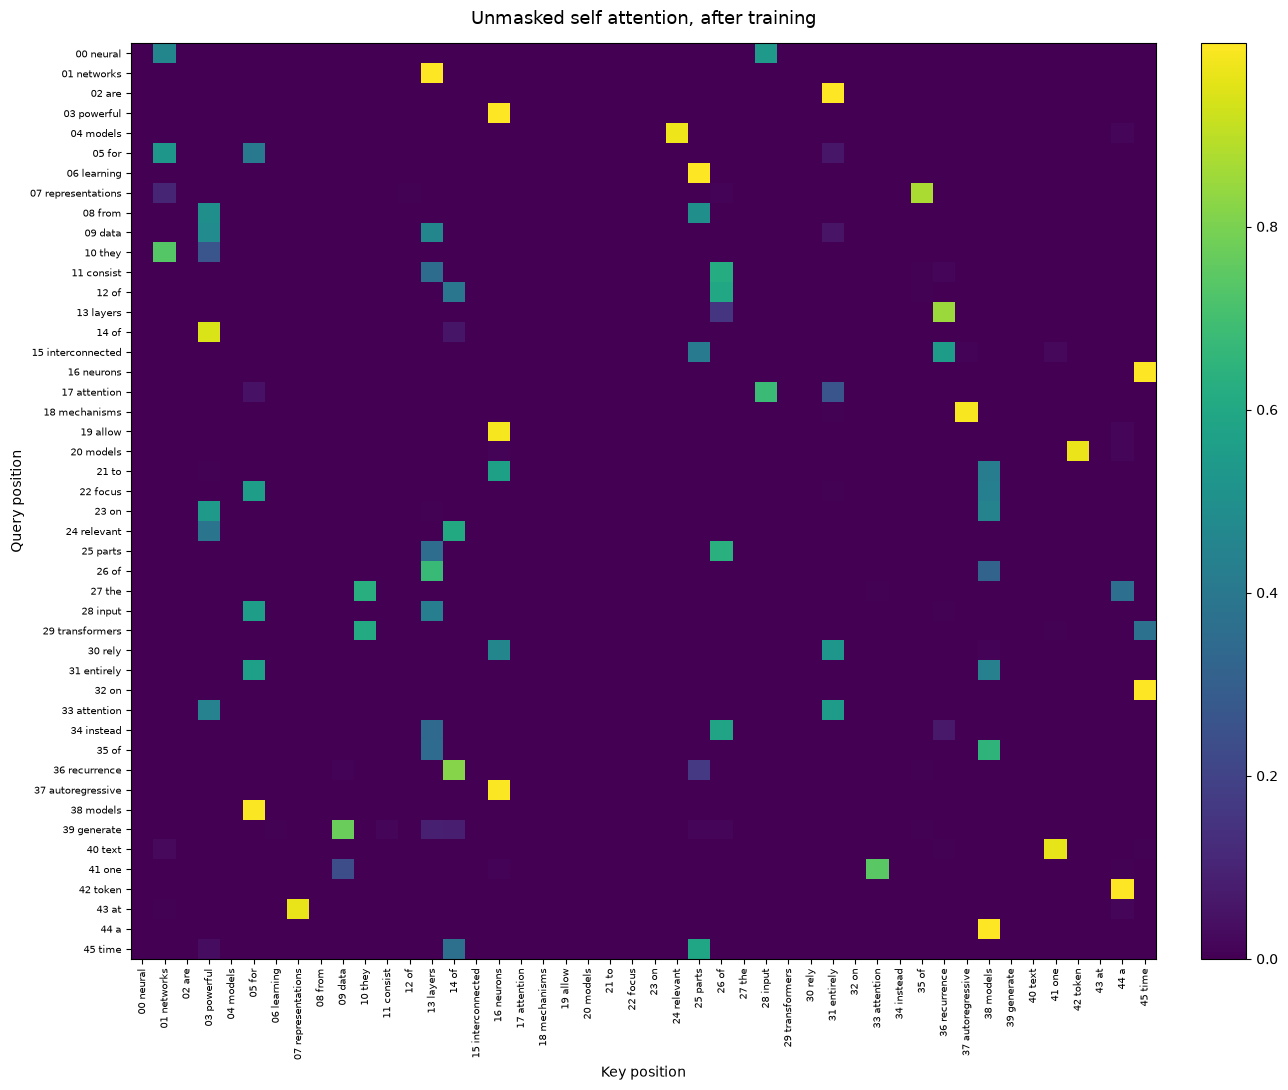

In [8]:
def plot_attention(weights, tokens_, title, outfile=None):
    fig, ax = plt.subplots(figsize=(13, 11))
    im = ax.imshow(weights, cmap="viridis", aspect="auto", vmin=0.0)
    ax.set_xticks(range(len(tokens_))); ax.set_yticks(range(len(tokens_)))
    ax.set_xticklabels(tokens_, rotation=90, fontsize=7)
    ax.set_yticklabels(tokens_, fontsize=7)
    ax.set_xlabel("Key position"); ax.set_ylabel("Query position")
    ax.set_title(title, fontsize=13, pad=14)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    if outfile:
        fig.savefig(outfile, dpi=150, bbox_inches="tight")
    plt.show()


plot_attention(attn_unmasked, labels, "Unmasked self attention, after training",
               outfile=f"{DATA}/attn_unmasked_trained.png")


#### 2.3.6 Observations

Training changes the attention map from close to uniform (mean row maximum near the uniform
value of 1/46) to sharply peaked, so the heatmap above reflects learned structure rather than
random initialization. The learned pattern is not a simple lookahead stripe: attention is
spread across many positions, and a large share of it lands on tokens that come after the
query position, which the next section shows the model was not supposed to be allowed to do.


### 2.4 Part 2: Causal Masking

#### 2.4.1 Causal Mask Implementation

A lower triangular mask: entry (i, j) is 1 when j is less than or equal to i, and 0 when j is
in the future. Applied to the scores before softmax by setting blocked entries to negative
infinity, which softmax turns into exactly zero.


In [9]:
def causal_mask(seq_len, device=None):
    return torch.tril(torch.ones(seq_len, seq_len, dtype=torch.long, device=device))


mask = causal_mask(len(tokens), device=device)
print(mask[:6, :6].numpy())


[[1 0 0 0 0 0]
 [1 1 0 0 0 0]
 [1 1 1 0 0 0]
 [1 1 1 1 0 0]
 [1 1 1 1 1 0]
 [1 1 1 1 1 1]]


#### 2.4.2 Recomputed Masked Attention Weights

Part 1 and Part 2 are two separately trained models. A second `TinyAttentionLM` is trained
from scratch with the causal mask applied during training, so it never has access to future
tokens at any point, which is what makes it a properly autoregressive model rather than the
Part 1 model with a mask bolted on afterward.


In [10]:
torch.manual_seed(SEED)
model_masked = TinyAttentionLM(vocab_size).to(device)
history_masked = train(model_masked, inputs, targets, mask=mask, label="masked")

model_masked.eval()
with torch.no_grad():
    _, attn_masked_t = model_masked(seq, mask=mask)
attn_masked = attn_masked_t[0].cpu().numpy()

upper = np.triu(attn_masked, k=1)
print(f"Largest attention weight above the diagonal: {upper.max():.10f}")
print(f"Every row still sums to 1: {np.allclose(attn_masked.sum(axis=1), 1.0)}")


[masked] epoch    1  loss 3.6939  accuracy 0.043
[masked] epoch  200  loss 0.0654  accuracy 1.000
[masked] epoch  400  loss 0.0329  accuracy 0.978
[masked] epoch  600  loss 0.0308  accuracy 0.978
Largest attention weight above the diagonal: 0.0000000000
Every row still sums to 1: True


#### 2.4.3 Heatmap Visualization: Masked Attention


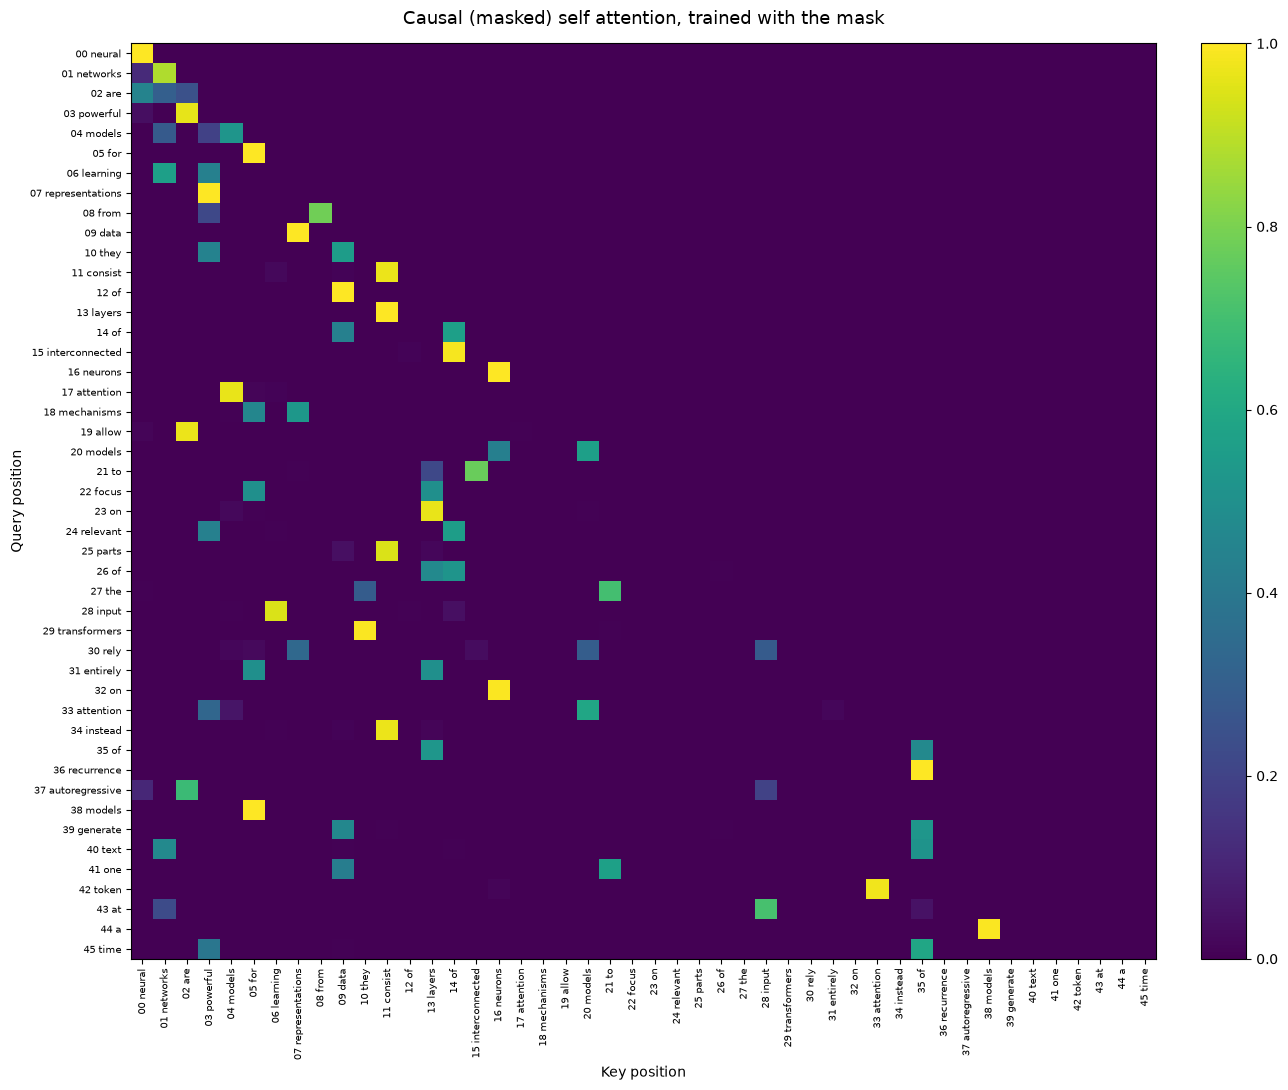

In [11]:
plot_attention(attn_masked, labels, "Causal (masked) self attention, trained with the mask",
               outfile=f"{DATA}/attn_masked.png")


#### 2.4.4 Observations

Every entry above the diagonal is exactly 0, not merely small, and every row still sums to 1,
so no token attends to a future position. Comparing the two properly trained models: the
Part 1 model, trained with no mask, reaches a next token accuracy of 1.000 because it can
look ahead; the Part 2 model, trained under the causal mask throughout, has strictly less
information available at each position and converges to a lower accuracy, computed below.


In [12]:
def next_token_accuracy(model_, inputs_, targets_, mask=None):
    model_.eval()
    with torch.no_grad():
        logits, _ = model_(inputs_, mask=mask)
        acc = (logits.argmax(-1) == targets_).float().mean().item()
    return acc


acc_unmasked_model = next_token_accuracy(model, inputs, targets, mask=None)
acc_masked_model = next_token_accuracy(model_masked, inputs, targets, mask=mask)
print(f"Part 1 model (trained without a mask), accuracy: {acc_unmasked_model:.3f}")
print(f"Part 2 model (trained with the causal mask), accuracy: {acc_masked_model:.3f}")


Part 1 model (trained without a mask), accuracy: 1.000
Part 2 model (trained with the causal mask), accuracy: 0.978


Secondary experiment: what if the causal mask is instead applied only at test time, to
the Part 1 model that was never trained with it? This is not the primary Part 1 vs Part 2
comparison above, but it shows how much the unmasked model was relying on future tokens
during training.


In [13]:
acc_posthoc = next_token_accuracy(model, inputs, targets, mask=mask)
print(f"Part 1 model, mask applied only at test time: {acc_posthoc:.3f}")


Part 1 model, mask applied only at test time: 0.391


## 3. Conclusion and Final Findings Summary

No prompt engineering technique solved both tasks. Chain of Thought and Zero Shot Chain of
Thought both solved the math problem by working through the two phases of the timeline in
order; Tree of Thoughts alone solved the logic puzzle because it could discard a branch after
generating it, something none of the linear techniques can do. More visible reasoning was not
the same as more correct reasoning: several techniques produced fluent, confident, and wrong
chains of reasoning on the logic puzzle, each committing early to one seating and never
revisiting it.

For self attention, training took the unmasked model's attention map from close to uniform
to sharply peaked, confirming the Part 1 heatmap reflects learned structure. That model
relied on attending to future positions, reaching a next token accuracy of 1.000 with no
mask at all. The Part 2 model, trained separately and entirely under the causal mask, never
had that option: every future entry in its attention matrix is exactly 0 and every row still
sums to 1, and it converges to a lower accuracy because it genuinely has less information
available at each position. Together the two parts of this assignment show the same
underlying lesson from different angles: a model's fluent output, whether a chain of
reasoning or a low training loss, is not on its own evidence that it solved the problem the
intended way.
